# Sales Data
## Automated Data: Minimal Cleaning Needed

Goals: ID most popular items, ID most profitable items

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales = pd.read_csv('/work/TotalSales.csv', encoding = 'latin-1')

In [3]:
sales.describe()

,Net items sold,Gross sales,Discounts,Returns,Net sales,Taxes,Total sales
count,3009.000000,3009.000000,3009.000000,3009.000000,3009.000000,3009.000000,3009.000000
mean,10.466268,480.148637,-13.458026,-7.845404,458.845208,25.708455,484.553662
std,93.428738,5553.984556,129.858635,130.186981,5314.777390,270.784863,5584.492830
min,0.000000,0.000000,-6746.230000,-6600.000000,0.000000,0.000000,0.000000
25%,1.000000,48.000000,-5.500000,0.000000,44.000000,2.400000,46.640000
50%,2.000000,80.000000,0.000000,0.000000,75.000000,4.320000,79.500000
75%,4.000000,176.000000,0.000000,0.000000,168.000000,9.600000,178.080000
max,4419.000000,250162.950000,0.000000,0.000000,236816.720000,11238.890000,248055.610000


In [4]:
sales.shape

(3009, 10)

In [5]:
sales.head()

,Product title,Product variant title,Product variant SKU,Net items sold,Gross sales,Discounts,Returns,Net sales,Taxes,Total sales
0,NaN,NaN,NaN,4419,250162.95,-6746.23,-6600.0,236816.72,11238.89,248055.61
1,Ring Making Workshops,Stacker Ring Class (14k Gold Filled or Sterlin...,NaN,2079,153071.21,-1111.90,-1878.0,150081.31,8519.73,158601.04
2,Ring Making Workshops,Gemstone Ring Class ( Sterling Silver) ONE RING,NaN,381,50840.00,-331.00,-1465.0,49044.00,2711.34,51755.34
3,Bracelet - Permanent Jewelry,Maya Chain GF,FigaroMiniGF,344,19912.00,-308.52,-112.0,19491.48,1169.48,20660.96
4,Bracelet - Permanent Jewelry,Marisa GF,MarisaGF,401,19480.00,-243.33,0.0,19236.67,1154.21,20390.88


### Categories

In [6]:
# print unique value of the product title
exclude_strings = ['Bracelet|Hand Chain|Band', 'Shoes', 'Jeans|Denim', 'Headphones|Earbuds', 'Anklets', 'Candle|Diffuser', 'Ring', 'Studs|Hoops', 'Necklace', 'Charms', 'Case']
pattern = '|'.join(exclude_strings)
filtered_sales = sales[~sales['Product title'].str.contains(pattern, case=False, regex=True, na=False)]
filtered_sales

,Product title,Product variant title,Product variant SKU,Net items sold,Gross sales,Discounts,Returns,Net sales,Taxes,Total sales
0,NaN,NaN,NaN,4419,250162.95,-6746.23,-6600.0,236816.72,11238.89,248055.61
79,Permanent Jewelry Repair,Repair / Reweld Non-HC,NaN,137,2171.00,-28.95,-18.0,2124.05,127.45,2251.50
88,Anklet upgrade Perm,Default Title,NaN,165,1980.00,-0.40,0.0,1979.60,118.78,2098.38
111,Wick Trimmer,Default Title,45084289169970,194,1688.00,-90.50,-30.0,1567.50,68.46,1635.96
159,Permanent Jewelry Repair,2nd Repair HC/ Non HC Reweld,NaN,58,1050.00,-36.50,-14.4,999.10,59.94,1059.04
...,...,...,...,...,...,...,...,...,...,...
3000,Black Friday Mystery Gift,M37,M37,1,0.00,0.00,0.0,0.00,0.00,0.00
3001,Black Friday Mystery Gift,M10,M10,2,0.00,0.00,0.0,0.00,0.00,0.00
3005,Black Friday Mystery Gift,M17,M17,1,0.00,0.00,0.0,0.00,0.00,0.00
3006,Bold Curb Chain,Sterling Silver / 24,BCURB-SS-24,0,188.00,0.00,-188.0,0.00,0.00,0.00


In [7]:
# Create categories
conditions = [
    sales['Product title'].str.contains('Bracelet|Hand Chain|Band|Bangle', case=False, na=False),
    sales['Product title'].str.contains('Shoes', case=False, na=False),
    sales['Product title'].str.contains('Headphones|Earbuds', case=False, na=False),
    sales['Product title'].str.contains('Anklets', case=False, na=False),
    sales['Product title'].str.contains('Candle|Diffuser|Spray', case=False, na=False),
    sales['Product title'].str.contains('Ring', case=False, na=False),
    sales['Product title'].str.contains('Studs|Hoops|Cuff', case=False, na=False),
    sales['Product title'].str.contains('Necklace|Chain|Pendant|PBC', case=False, na=False),
    sales['Product title'].str.contains('Charm', case=False, na=False),
]

categories = [
    'Bracelet',
    'Shoes',
    'Headphones',
    'Anklet',
    'Candle/Diffuser',
    'Ring',
    'Earrings',
    'Necklace/Chain',
    'Charm'
]
sales['Category'] = np.select(conditions, categories, default='Others')
print(sales['Category'].value_counts())

Category
Bracelet           847
Ring               764
Necklace/Chain     442
Charm              306
Candle/Diffuser    244
Others             172
Earrings           160
Anklet              74
Name: count, dtype: int64


In [8]:
sales.head()

,Product title,Product variant title,Product variant SKU,Net items sold,Gross sales,Discounts,Returns,Net sales,Taxes,Total sales,Category
0,NaN,NaN,NaN,4419,250162.95,-6746.23,-6600.0,236816.72,11238.89,248055.61,Others
1,Ring Making Workshops,Stacker Ring Class (14k Gold Filled or Sterlin...,NaN,2079,153071.21,-1111.90,-1878.0,150081.31,8519.73,158601.04,Ring
2,Ring Making Workshops,Gemstone Ring Class ( Sterling Silver) ONE RING,NaN,381,50840.00,-331.00,-1465.0,49044.00,2711.34,51755.34,Ring
3,Bracelet - Permanent Jewelry,Maya Chain GF,FigaroMiniGF,344,19912.00,-308.52,-112.0,19491.48,1169.48,20660.96,Bracelet
4,Bracelet - Permanent Jewelry,Marisa GF,MarisaGF,401,19480.00,-243.33,0.0,19236.67,1154.21,20390.88,Bracelet


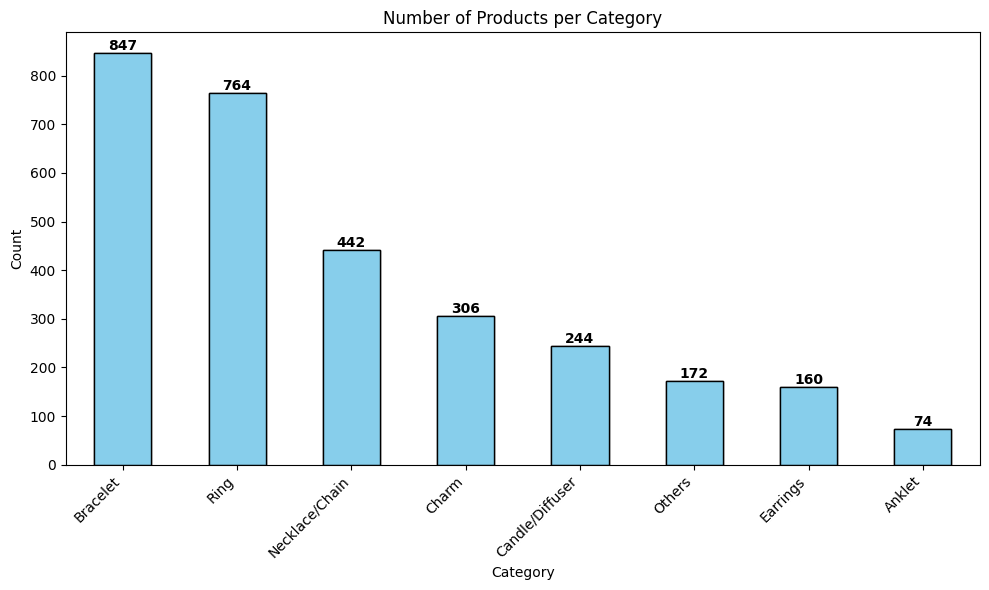

In [9]:
category_counts = sales['Category'].value_counts()
plt.figure(figsize=(10, 6))
bars = category_counts.plot(kind='bar', color='skyblue', edgecolor='black')
category_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Products per Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, value in enumerate(category_counts):
    plt.text(i, value + 0.1, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
import plotly.express as px

# Count products per category
category_counts = sales['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

# Create bar chart
fig = px.bar(
    category_counts,
    x='Category',
    y='Count',
    text='Count',
    title='Number of Products per Category',
    color_discrete_sequence=['skyblue']  # match matplotlib color
)

# Label and style
fig.update_traces(
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Category',
    yaxis_title='Count',
    template='simple_white',
    height=600,
    paper_bgcolor='#EAEAEA',  # overall background
    plot_bgcolor='#EAEAEA',   # chart area background
    margin=dict(t=80, b=100), # space for rotated labels
    font=dict(size=12),
)

fig.update_xaxes(tickangle=-45)

fig.show()


In [11]:
category_counts = sales['Category'].value_counts()
sales['CategoryTotalSold'] = sales['Category'].map(category_counts) * sales['Net items sold']
sales.head()

,Product title,Product variant title,Product variant SKU,Net items sold,Gross sales,Discounts,Returns,Net sales,Taxes,Total sales,Category,CategoryTotalSold
0,NaN,NaN,NaN,4419,250162.95,-6746.23,-6600.0,236816.72,11238.89,248055.61,Others,760068
1,Ring Making Workshops,Stacker Ring Class (14k Gold Filled or Sterlin...,NaN,2079,153071.21,-1111.90,-1878.0,150081.31,8519.73,158601.04,Ring,1588356
2,Ring Making Workshops,Gemstone Ring Class ( Sterling Silver) ONE RING,NaN,381,50840.00,-331.00,-1465.0,49044.00,2711.34,51755.34,Ring,291084
3,Bracelet - Permanent Jewelry,Maya Chain GF,FigaroMiniGF,344,19912.00,-308.52,-112.0,19491.48,1169.48,20660.96,Bracelet,291368
4,Bracelet - Permanent Jewelry,Marisa GF,MarisaGF,401,19480.00,-243.33,0.0,19236.67,1154.21,20390.88,Bracelet,339647


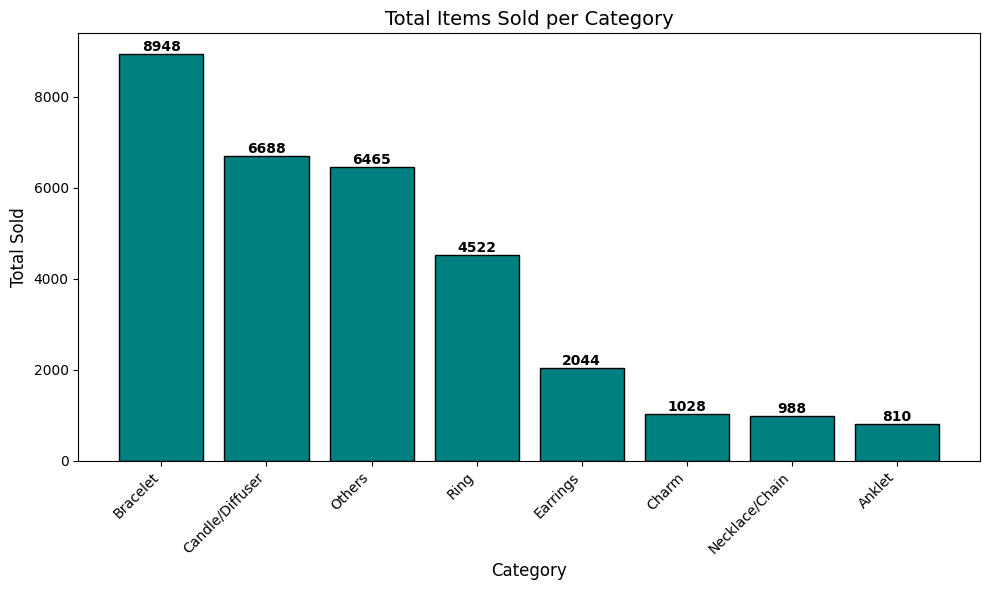

In [12]:
category_summary = (
    sales.groupby('Category', as_index=False)['Net items sold']
    .sum()
    .rename(columns={'Net items sold': 'Total Sold'})
    .sort_values(by='Total Sold', ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(category_summary['Category'], category_summary['Total Sold'],
               color='teal', edgecolor='black')

plt.title('Total Items Sold per Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, height,
        f'{int(height)}',  # format number
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )
plt.tight_layout()
plt.show()

In [13]:
import plotly.express as px

# Summarize total sold by category
category_summary = (
    sales.groupby('Category', as_index=False)['Net items sold']
         .sum()
         .rename(columns={'Net items sold': 'Total Sold'})
         .sort_values(by='Total Sold', ascending=False)
)

# Create Plotly bar chart
fig = px.bar(
    category_summary,
    x='Category',
    y='Total Sold',
    text='Total Sold',
    title='Total Items Sold per Category',
    color_discrete_sequence=['teal']  # same color as matplotlib version
)

# Style and formatting
fig.update_traces(
    texttemplate='%{text:,}',  # comma formatting
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Category',
    yaxis_title='Total Sold',
    template='simple_white',
    paper_bgcolor='#EAEAEA',  # figure background
    plot_bgcolor='#EAEAEA',   # chart area background
)

fig.update_xaxes(tickangle=-45)

fig.show()


In [14]:
# Create categories
variant_conditions = [
    sales['Product variant title'].str.contains('Gold Filled|GF', case=False, na=False),
    sales['Product variant title'].str.contains('SS', case=False, na=False),
    sales['Product variant title'].str.contains('OZ', case=False, na=False),
]

variant_categories = [
    'Gold Filled|GF',
    'SS',
    'OZ',
]

sales['variant_categories'] = np.select(variant_conditions, variant_categories, default='Others')
print(sales['variant_categories'].value_counts())

variant_categories
Others            1577
Gold Filled|GF    1060
SS                 239
OZ                 133
Name: count, dtype: int64


### Seperate within Categories Based on SS or GF

In [15]:
Bracelet=sales[sales['Category']=="Bracelet"]

In [16]:
# Create categories
variant_Bracelet = [
    Bracelet['Product variant title'].str.contains('Gold Filled|GF', case=False, na=False),
    Bracelet['Product variant title'].str.contains('Sterling Silver|SS', case=False, na=False),
]

variant_catogories_Bracelet = [
    'Gold Filled|GF',
    'Sterling Silver|SS'
]

Bracelet['variant_Bracelet'] = np.select(variant_Bracelet, variant_catogories_Bracelet, default='Others')
print(Bracelet['variant_Bracelet'].value_counts())

variant_Bracelet
Gold Filled|GF        406
Sterling Silver|SS    293
Others                148
Name: count, dtype: int64
/tmp/ipykernel_158/3929127285.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



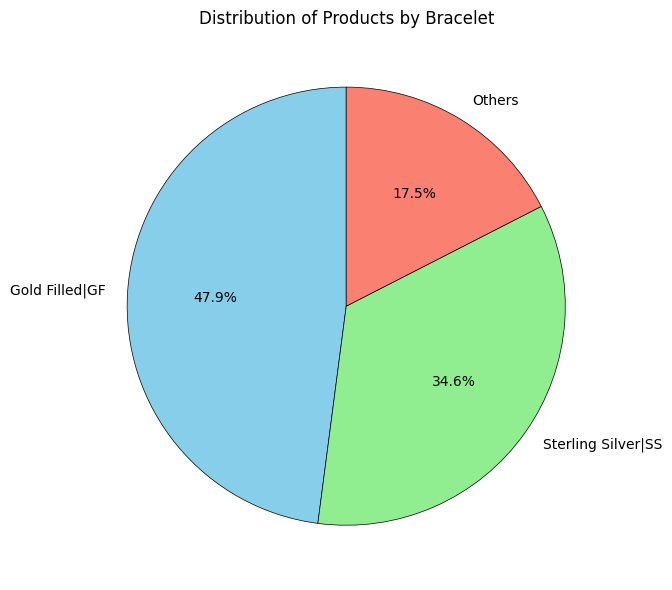

In [17]:
Bracelet_counts = Bracelet['variant_Bracelet'].value_counts()

plt.figure(figsize=(10, 6))
Bracelet_counts.plot(
    kind='pie', 
    autopct='%1.1f%%',  
    startangle=90,
    colors=['skyblue', 'lightgreen', 'salmon', 'gold'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)

plt.title('Distribution of Products by Bracelet')
plt.ylabel('')  
plt.tight_layout()
plt.show()

In [18]:
import plotly.express as px

# Count bracelet variants
Bracelet_counts = Bracelet['variant_Bracelet'].value_counts().reset_index()
Bracelet_counts.columns = ['Bracelet Type', 'Count']

# Create pie chart
fig = px.pie(
    Bracelet_counts,
    names='Bracelet Type',
    values='Count',
    title='Distribution of Products by Bracelet',
)

# Style labels and layout
fig.update_traces(
    textposition='inside',
    textinfo='percent+label',   # show both % and label
)

fig.update_layout(
    paper_bgcolor='#EAEAEA',  # entire figure background
    plot_bgcolor='#EAEAEA',   # chart area background
    showlegend=False
)

fig.show()


In [19]:
variant_counts_bracelet = Bracelet['variant_Bracelet'].value_counts()
Bracelet['VariantTotalSold'] = Bracelet['variant_Bracelet'].map(variant_counts_bracelet) * Bracelet['Net items sold']

variant_summary_bracelet = (
    Bracelet.groupby('variant_Bracelet', as_index=False)['VariantTotalSold']
    .sum()
    .sort_values(by='VariantTotalSold', ascending=False)
)

print(variant_summary_bracelet)


     variant_Bracelet  VariantTotalSold
0      Gold Filled|GF           2283344
2  Sterling Silver|SS            753010
1              Others            111592
/tmp/ipykernel_158/2001147671.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



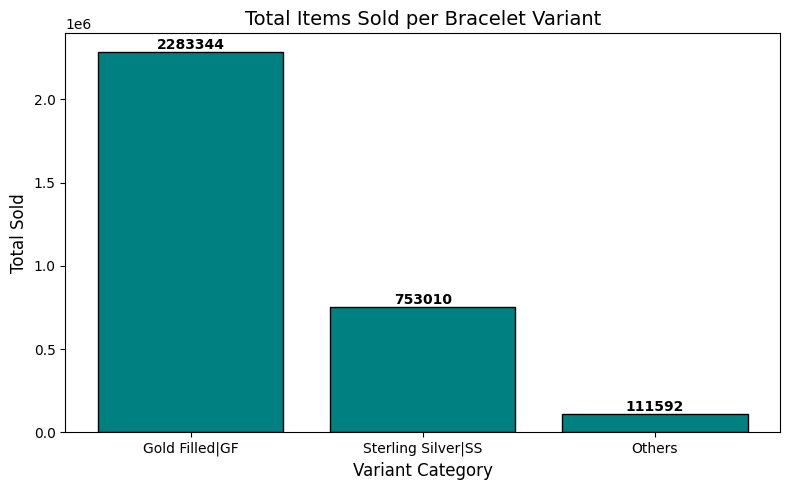

In [20]:
plt.figure(figsize=(8, 5))
bars_b = plt.bar(variant_summary_bracelet['variant_Bracelet'], variant_summary_bracelet['VariantTotalSold'],
               color='teal', edgecolor='black')

plt.title('Total Items Sold per Bracelet Variant', fontsize=14)
plt.xlabel('Variant Category', fontsize=12)
plt.ylabel('Total Sold', fontsize=12)
plt.xticks(rotation=0)

for bar in bars_b:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, height,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [21]:
import plotly.express as px

# Assuming variant_summary_bracelet is already defined:
# Columns: ['variant_Bracelet', 'VariantTotalSold']

fig = px.bar(
    variant_summary_bracelet,
    x='variant_Bracelet',
    y='VariantTotalSold',
    text='VariantTotalSold',
    title='Total Items Sold per Bracelet Variant',
    color_discrete_sequence=['teal']  # same as your Matplotlib color
)

# Label formatting and styling
fig.update_traces(
    texttemplate='%{text:,}',  # comma format for large numbers
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Variant Category',
    yaxis_title='Total Sold',
    template='simple_white',
    paper_bgcolor='#EAEAEA',  # full background
    plot_bgcolor='#EAEAEA',   # chart area
)

# Keep x labels horizontal (rotation = 0)
fig.update_xaxes(tickangle=0)

fig.show()


In [22]:
Ring = sales[sales['Category']=="Ring"]

In [23]:
# Create categories
variant_Ring = [
    Ring['Product variant title'].str.contains('Gold Filled|GF', case=False, na=False),
    Ring['Product variant title'].str.contains('Sterling Silver|SS', case=False, na=False),
]

variant_catogories_Ring = [
    'Gold Filled|GF',
    'Sterling Silver|SS'
]

Ring['variant_Ring'] = np.select(variant_Ring, variant_catogories_Ring, default='Others')
print(Ring['variant_Ring'].value_counts())

variant_Ring
Others                386
Gold Filled|GF        213
Sterling Silver|SS    165
Name: count, dtype: int64
/tmp/ipykernel_158/1382405213.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



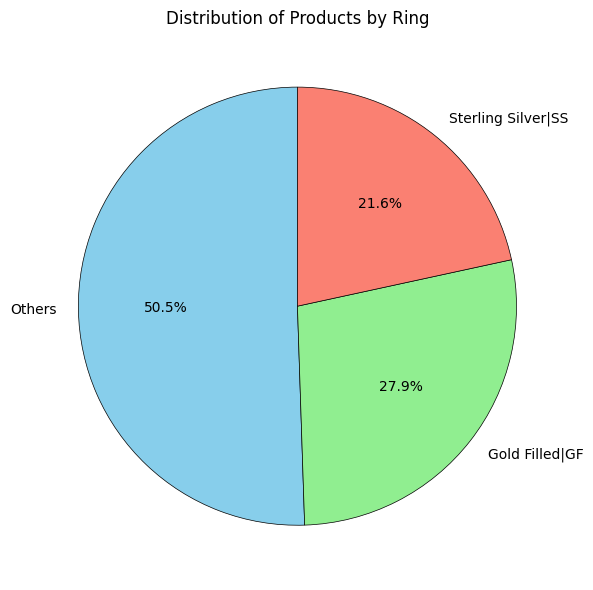

In [24]:
Ring_counts = Ring['variant_Ring'].value_counts()

plt.figure(figsize=(10, 6))
Ring_counts.plot(
    kind='pie', 
    autopct='%1.1f%%',  
    startangle=90,
    colors=['skyblue', 'lightgreen', 'salmon', 'gold'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)

plt.title('Distribution of Products by Ring')
plt.ylabel('')  
plt.tight_layout()
plt.show()

In [25]:
import plotly.express as px

# Count ring variants
Ring_counts = Ring['variant_Ring'].value_counts().reset_index()
Ring_counts.columns = ['Ring Type', 'Count']

fig = px.pie(
    Ring_counts,
    names='Ring Type',
    values='Count',
    title='Distribution of Products by Ring')

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.update_layout(
    paper_bgcolor='#EAEAEA',
    plot_bgcolor='#EAEAEA'
)

fig.show()


         variant_Ring  VariantTotalSold
0      Gold Filled|GF            636657
1              Others            274060
2  Sterling Silver|SS            135795
/tmp/ipykernel_158/602616534.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



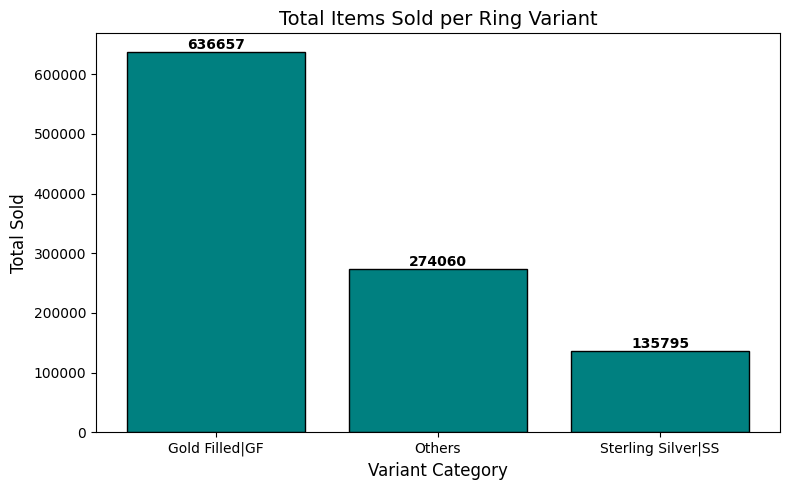

In [26]:
variant_counts_Ring = Ring['variant_Ring'].value_counts()
Ring['VariantTotalSold'] = Ring['variant_Ring'].map(variant_counts_Ring) * Ring['Net items sold']

variant_summary_ring = (
    Ring.groupby('variant_Ring', as_index=False)['VariantTotalSold']
    .sum()
    .sort_values(by='VariantTotalSold', ascending=False)
)

print(variant_summary_ring)

plt.figure(figsize=(8, 5))
bars_r = plt.bar(variant_summary_ring['variant_Ring'], variant_summary_ring['VariantTotalSold'],
               color='teal', edgecolor='black')

plt.title('Total Items Sold per Ring Variant', fontsize=14)
plt.xlabel('Variant Category', fontsize=12)
plt.ylabel('Total Sold', fontsize=12)
plt.xticks(rotation=0)

for bar in bars_r:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, height,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [27]:
import plotly.express as px

# Assuming variant_summary_ring is already defined:
# Columns: ['variant_Ring', 'VariantTotalSold']

fig = px.bar(
    variant_summary_ring,
    x='variant_Ring',
    y='VariantTotalSold',
    text='VariantTotalSold',
    title='Total Items Sold per Ring Variant',
    color_discrete_sequence=['teal']  # consistent with other jewelry plots
)

# Label formatting and styling
fig.update_traces(
    texttemplate='%{text:,}',  # comma formatting for readability
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Variant Category',
    yaxis_title='Total Sold',
    template='simple_white',
    paper_bgcolor='#EAEAEA',  # full figure background
    plot_bgcolor='#EAEAEA',   # chart area background
)

# Keep x labels horizontal
fig.update_xaxes(tickangle=0)

fig.show()


In [28]:
Necklace=sales[sales['Category']=="Necklace/Chain"]

In [29]:
# Create categories
variant_Necklace = [
    Necklace['Product variant title'].str.contains('Gold Filled|GF', case=False, na=False),
    Necklace['Product variant title'].str.contains('Sterling Silver|SS', case=False, na=False),
]

variant_catogories_Necklace = [
    'Gold Filled|GF',
    'Sterling Silver|SS'
]

Necklace['variant_Necklace'] = np.select(variant_Necklace, variant_catogories_Necklace, default='Others')
print(Necklace['variant_Necklace'].value_counts())

variant_Necklace
Gold Filled|GF        170
Sterling Silver|SS    137
Others                135
Name: count, dtype: int64
/tmp/ipykernel_158/3963917643.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



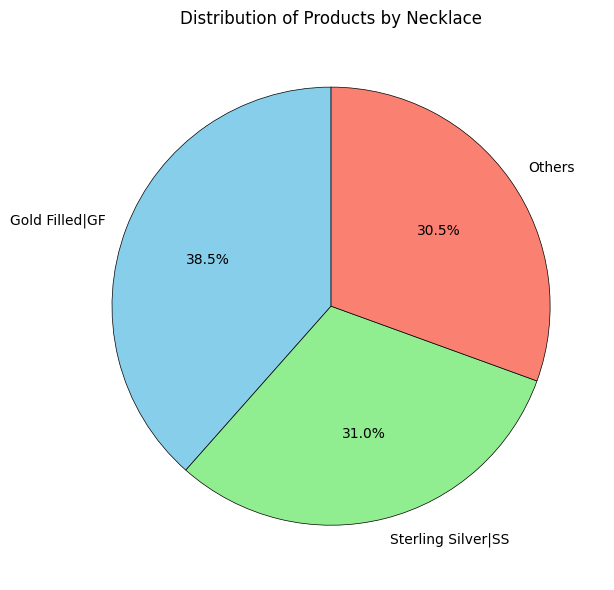

In [30]:
Necklace_counts = Necklace['variant_Necklace'].value_counts()

plt.figure(figsize=(10, 6))
Necklace_counts.plot(
    kind='pie', 
    autopct='%1.1f%%',  
    startangle=90,
    colors=['skyblue', 'lightgreen', 'salmon', 'gold'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)

plt.title('Distribution of Products by Necklace')
plt.ylabel('')  
plt.tight_layout()
plt.show()

In [31]:
import plotly.express as px

# Count necklace variants
Necklace_counts = Necklace['variant_Necklace'].value_counts().reset_index()
Necklace_counts.columns = ['Necklace Type', 'Count']

fig = px.pie(
    Necklace_counts,
    names='Necklace Type',
    values='Count',
    title='Distribution of Products by Necklace',
a)

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.update_layout(
    paper_bgcolor='#EAEAEA',
    plot_bgcolor='#EAEAEA'
)

fig.show()


SyntaxError: positional argument follows keyword argument (4067316539.py, line 12)

In [31]:
variant_counts_Necklace = Necklace['variant_Necklace'].value_counts()
Necklace['VariantTotalSold'] = Necklace['variant_Necklace'].map(variant_counts_Necklace) * Necklace['Net items sold']

variant_summary_necklace = (
    Necklace.groupby('variant_Necklace', as_index=False)['VariantTotalSold']
    .sum()
    .sort_values(by='VariantTotalSold', ascending=False)
)


/tmp/ipykernel_147/71588792.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



     variant_Necklace  VariantTotalSold
0      Gold Filled|GF             85000
2  Sterling Silver|SS             40415
1              Others             26055


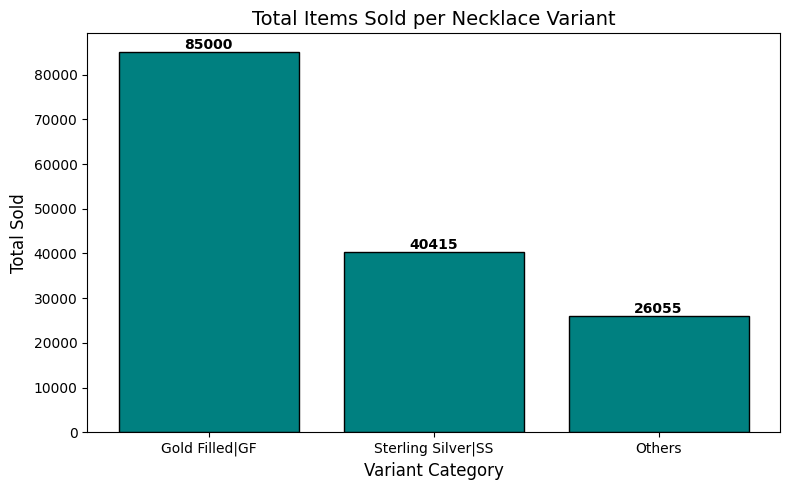

In [32]:
print(variant_summary_necklace)

plt.figure(figsize=(8, 5))
bars_n = plt.bar(variant_summary_necklace['variant_Necklace'], variant_summary_necklace['VariantTotalSold'],
               color='teal', edgecolor='black')

plt.title('Total Items Sold per Necklace Variant', fontsize=14)
plt.xlabel('Variant Category', fontsize=12)
plt.ylabel('Total Sold', fontsize=12)
plt.xticks(rotation=0)

for bar in bars_n:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, height,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [33]:
import plotly.express as px

# Assuming variant_summary_necklace is already defined:
# Columns: ['variant_Necklace', 'VariantTotalSold']

fig = px.bar(
    variant_summary_necklace,
    x='variant_Necklace',
    y='VariantTotalSold',
    text='VariantTotalSold',
    title='Total Items Sold per Necklace Variant',
    color_discrete_sequence=['teal']  # consistent with other variant charts
)

# Label formatting and styling
fig.update_traces(
    texttemplate='%{text:,}',  # adds commas to large values
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Variant Category',
    yaxis_title='Total Sold',
    template='simple_white',
    paper_bgcolor='#EAEAEA',  # full background
    plot_bgcolor='#EAEAEA')   # chart area background

# Keep x labels horizontal
fig.update_xaxes(tickangle=0)

fig.show()


In [34]:
Charm=sales[sales['Category']=="Charm"]

In [35]:
# Create categories
variant_Charm = [
    Charm['Product variant title'].str.contains('Gold Filled|GF', case=False, na=False),
    Charm['Product variant title'].str.contains('Sterling Silver|SS', case=False, na=False),
]

variant_catogories_Charm = [
    'Gold Filled|GF',
    'Sterling Silver|SS'
]

Charm['variant_Charm'] = np.select(variant_Charm, variant_catogories_Charm, default='Others')
print(Charm['variant_Charm'].value_counts())

variant_Charm
Gold Filled|GF        172
Sterling Silver|SS    106
Others                 28
Name: count, dtype: int64
/tmp/ipykernel_147/2098649821.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



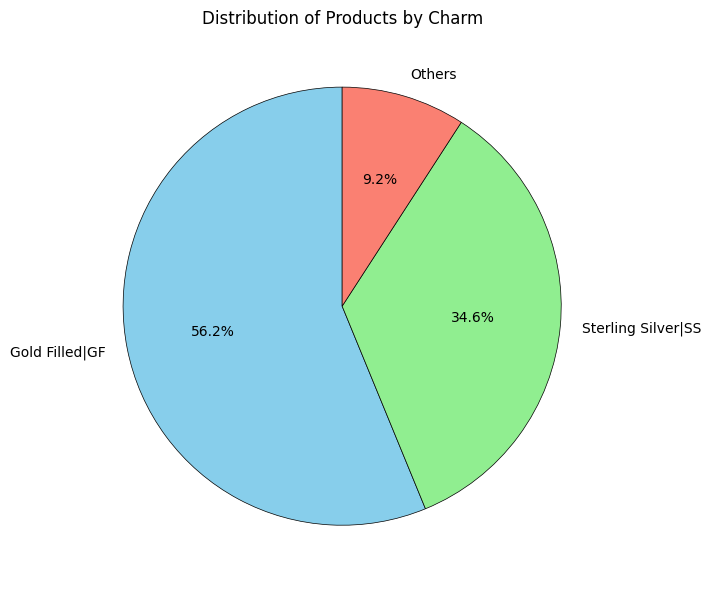

In [36]:
Charm_counts = Charm['variant_Charm'].value_counts()

plt.figure(figsize=(10, 6))
Charm_counts.plot(
    kind='pie', 
    autopct='%1.1f%%',  
    startangle=90,
    colors=['skyblue', 'lightgreen', 'salmon', 'gold'],
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.5}
)

plt.title('Distribution of Products by Charm')
plt.ylabel('')  
plt.tight_layout()
plt.show()

In [45]:
import plotly.express as px

# Count charm variants
Charm_counts = Charm['variant_Charm'].value_counts().reset_index()
Charm_counts.columns = ['Charm Type', 'Count']

fig = px.pie(
    Charm_counts,
    names='Charm Type',
    values='Count',
    title='Distribution of Products by Charm')

fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.update_layout(
    paper_bgcolor='#EAEAEA',
    plot_bgcolor='#EAEAEA'
)

fig.show()



In [37]:
variant_counts_charm = Charm['variant_Charm'].value_counts()
Charm['VariantTotalSold'] = Charm['variant_Charm'].map(variant_counts_charm) * Charm['Net items sold']

variant_summary_charm = (
    Charm.groupby('variant_Charm', as_index=False)['VariantTotalSold']
    .sum()
    .sort_values(by='VariantTotalSold', ascending=False)
)

print(variant_summary_charm)

        variant_Charm  VariantTotalSold
0      Gold Filled|GF            101136
2  Sterling Silver|SS             34768
1              Others              3136
/tmp/ipykernel_147/2643542574.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



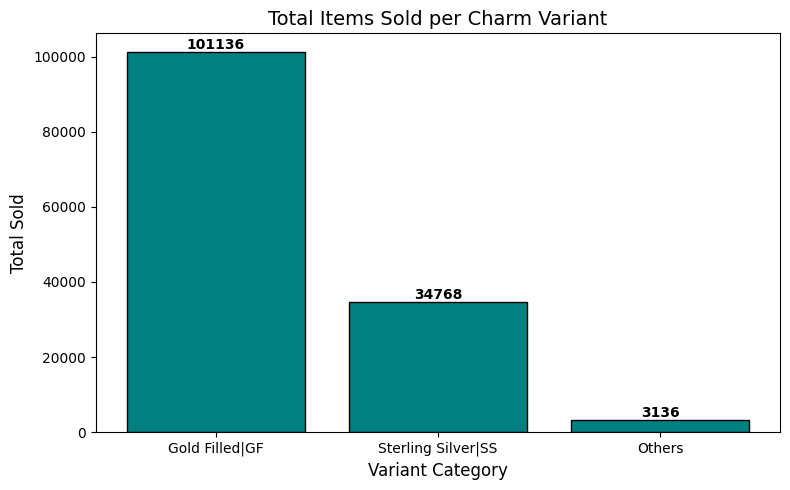

In [38]:
plt.figure(figsize=(8, 5))
bars_c = plt.bar(variant_summary_charm['variant_Charm'], variant_summary_charm['VariantTotalSold'],
               color='teal', edgecolor='black')

plt.title('Total Items Sold per Charm Variant', fontsize=14)
plt.xlabel('Variant Category', fontsize=12)
plt.ylabel('Total Sold', fontsize=12)
plt.xticks(rotation=0)

for bar in bars_c:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, height,
        f'{int(height)}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [39]:
import plotly.express as px

# Assuming variant_summary_charm is already defined:
# Columns: ['variant_Charm', 'VariantTotalSold']

fig = px.bar(
    variant_summary_charm,
    x='variant_Charm',
    y='VariantTotalSold',
    text='VariantTotalSold',
    title='Total Items Sold per Charm Variant',
    color_discrete_sequence=['teal']  # same color as previous charts
)

# Label formatting and styling
fig.update_traces(
    texttemplate='%{text:,}',  # comma-formatted counts
    textposition='outside'
)

fig.update_layout(
    xaxis_title='Variant Category',
    yaxis_title='Total Sold',
    template='simple_white',
    paper_bgcolor='#EAEAEA',  # overall background
    plot_bgcolor='#EAEAEA',   # chart area background
)

# Keep x-axis labels horizontal
fig.update_xaxes(tickangle=0)

fig.show()


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=65165b0f-3ecd-4b4c-bb31-a66c4e6fcba5' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>